In [78]:
import pyreadr
import pandas as pd
import numpy as np
import math
from collections import defaultdict, Counter
import os
from utils import plot_tree as pt
import webbrowser

# Caricamento dei dati dal file RDS
print("Caricamento dataset in corso...")
result = pyreadr.read_r('06_Cb_BTM_table.rds')
df = result[None]

# Filtraggio
ttype_selezionato = "ESAD"  #selezione del tumore
df_filtrato = df[df["ttype"] == ttype_selezionato].copy()

# Eliminazione geni sani (WT) e dati mancanti critici
df_filtrato = df_filtrato[df_filtrato['mutatation_status'] != "WT"]
df_filtrato = df_filtrato.dropna(subset=["clock_rank", "gene"])

print(f"Dataset filtrato per {ttype_selezionato}. Righe totali da analizzare: {len(df_filtrato)}")

df = df_filtrato[["sample_id","gene","clock_rank"]]

df.reset_index(drop=True, inplace=True)

Caricamento dataset in corso...
Dataset filtrato per ESAD. Righe totali da analizzare: 68


In [79]:
print("number of patients",len(df["sample_id"].unique()))

number of patients 24


In [93]:
import collections

input = collections.defaultdict(dict)

all_genes = df["gene"].unique().to_numpy()

for sample_id in df["sample_id"].unique():
    df_sample = df[df["sample_id"]==sample_id]
    #print(sample_id," con ranks ", df_sample["clock_rank"].unique())
    for rank in df_sample["clock_rank"].unique():
        df_s_rank = df_sample[df_sample["clock_rank"] == rank]
        genes = df_s_rank["gene"].to_numpy()
        result = np.isin(all_genes,genes)
        input[rank][sample_id]=result

len(input[1].keys())

18

/home/juan/venvs/lib/python3.13/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/juan/venvs/lib/python3.13/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/juan/venvs/lib/python3.13/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/juan/venvs/lib/python3.13/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


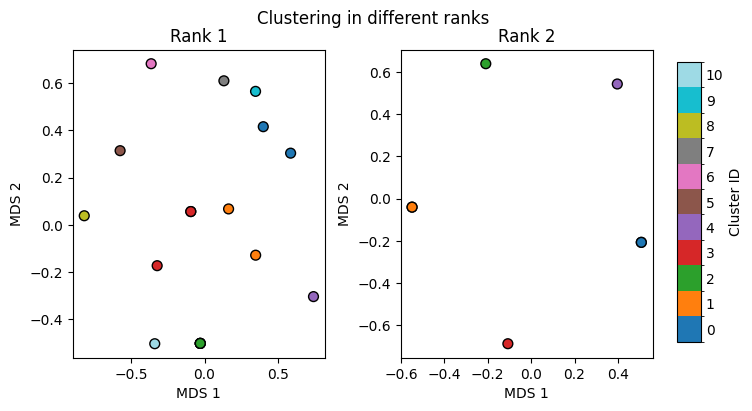

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import MDS


def get_number_clusters_from_silhouette(max_k, distance_matrix, linkage):
    silhouette_scores = []
    cluster_range = range(2, max_k)

    for k in cluster_range:
        hierarchical_cluster = AgglomerativeClustering(
            n_clusters=k, metric="precomputed", linkage=linkage
        )
        labels = hierarchical_cluster.fit_predict(distance_matrix)
        score = silhouette_score(distance_matrix, labels, metric="precomputed")
        silhouette_scores.append(score)

    k_best = cluster_range[np.argmax(silhouette_scores)]
    return k_best


linkage = "average"

distance_matrixes = {}
labelsels = {}
for rank in input.keys():
    X = np.array(list(input[rank].values()))
    if len(X) < 3:
        input.pop(rank)
        break
    distance_matrix = cdist(X, X, metric="jaccard")

    k = get_number_clusters_from_silhouette(len(X), distance_matrix, linkage)

    hierarchical_cluster = AgglomerativeClustering(
        n_clusters=k, metric="precomputed", linkage=linkage
    )

    labelsels[rank] = hierarchical_cluster.fit_predict(distance_matrix)
    distance_matrixes[rank] = distance_matrix

rank_names = list(input.keys())
n_cols = max(1, len(rank_names))


# 1. Create the figure, leaving a dedicated 15% margin on the right for the colorbar
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), squeeze=False)
plt.subplots_adjust(right=0.85, wspace=0.3)  # Explicitly reserves the right edge

# Unique label mapping setup
all_labels = []
for rank in rank_names:
    all_labels.extend(labelsels[rank])
unique_labels = sorted(list(set(all_labels)))

bounds = np.arange(len(unique_labels) + 1)
norm = mcolors.BoundaryNorm(bounds, ncolors=len(unique_labels))
cmap = plt.get_cmap("tab20", len(unique_labels))

for idx, rank in enumerate(rank_names):
    ax = axes[0, idx]
    distance_matrix = distance_matrixes[rank]
    labels = labelsels[rank]

    mapped_labels = [unique_labels.index(lbl) for lbl in labels]

    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    X_2d = mds.fit_transform(distance_matrix)

    scatter = ax.scatter(
        X_2d[:, 0], X_2d[:, 1], c=mapped_labels, cmap=cmap, norm=norm, edgecolors="k", s=50
    )
    ax.set_title(f"Rank {rank}")
    ax.set_xlabel("MDS 1")
    ax.set_ylabel("MDS 2")

fig.suptitle("Clustering in different ranks", y=0.98)

# 2. Explicitly define a bounding box for the colorbar on the far right edge
# Format: [left_position, bottom_position, width, height]
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])

# Create the colorbar in the independent box
cbar = fig.colorbar(
    scatter,
    cax=cbar_ax,
    ticks=bounds[:-1] + 0.5
)

# 1. REMOVE THE HORIZONTAL TICK MARKS (-)
cbar.ax.tick_params(length=0)

# 2. Set the text labels cleanly for every integer
cbar.ax.set_yticklabels([str(int(b)) for b in bounds[:-1]])
cbar.set_label("Cluster ID")

# NOTE: Avoid using plt.tight_layout() here as it overrides manual subplots_adjust
plt.show()


/home/juan/venvs/lib/python3.13/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


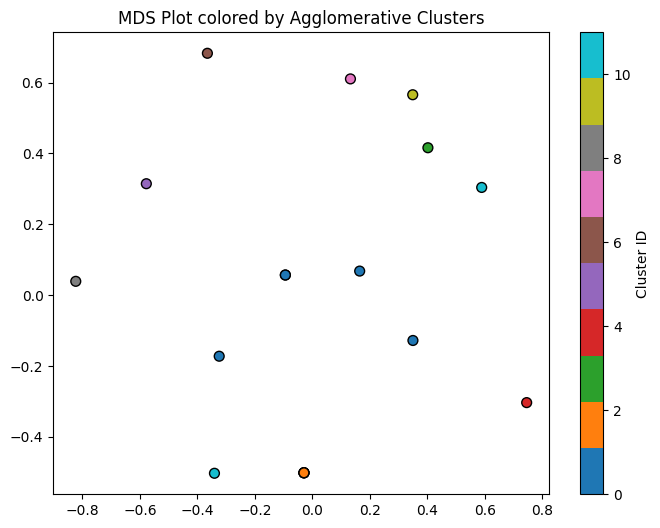

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist
from sklearn.manifold import MDS
from scipy.cluster.hierarchy import dendrogram, linkage

real_input = np.array(list(input[1].values()))

distance_matrix = cdist(real_input, real_input, metric='jaccard')

hierarchical_cluster = AgglomerativeClustering(n_clusters=12,metric="precomputed", linkage='average')

labels = hierarchical_cluster.fit_predict(distance_matrix)

# 2. Reduce dimensions to 2D using MDS
mds = MDS(n_components=2, metric='precomputed', random_state=42)
X_2d = mds.fit_transform(distance_matrix)

# 3. Plot and color by cluster label
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', edgecolors='k', s=50)

plt.title("MDS Plot colored by Agglomerative Clusters")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

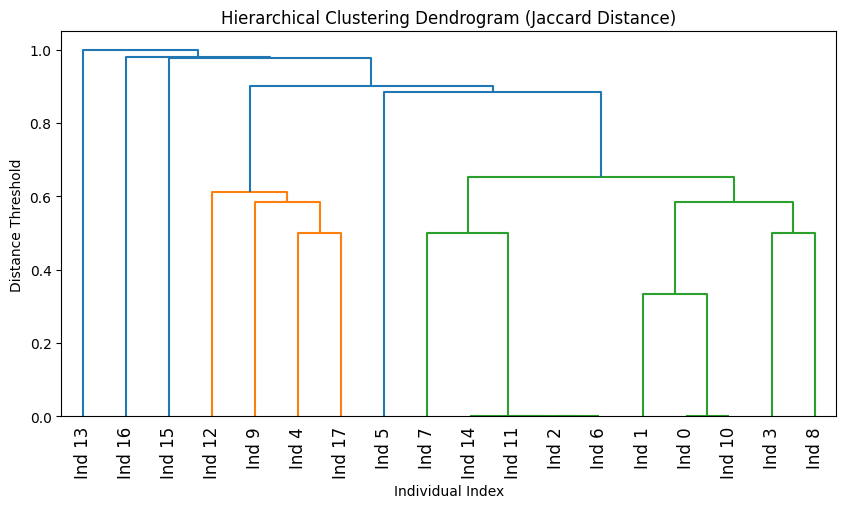

In [83]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Convert your 2D square distance matrix back into a 1D condensed array
condensed_distances = squareform(distance_matrix)

# 2. Generate the linkage matrix
# (Use 'average' or 'complete' for Jaccard distances)
Z = linkage(condensed_distances, method='average')

# 2. Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=[f"Ind {i}" for i in range(len(X_2d))], leaf_rotation=90)

plt.title("Hierarchical Clustering Dendrogram (Jaccard Distance)")
plt.xlabel("Individual Index")
plt.ylabel("Distance Threshold")
plt.show()